<a href="https://colab.research.google.com/github/stuart7824/pvr/blob/main/PVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv(r"/content/pvr_inox_standalone_is.csv",index_col=0)
df.head(5)

,2020,2021,2022,2023,2024,2025
Line Item,,,,,,
Operating Revenue,3284.1,245.2,1309.1,3449.1,5780.4,5442.4
Movie Exhibition,1844.7,109.8,683.8,1812.3,3012.3,2823.5
Food & Beverages,949.1,61.8,361.3,1031.5,1832.4,1663.3
Advertisement,361.8,15.1,136.2,332.1,432.1,404.2
Other,128.5,58.5,127.8,273.2,503.6,551.4


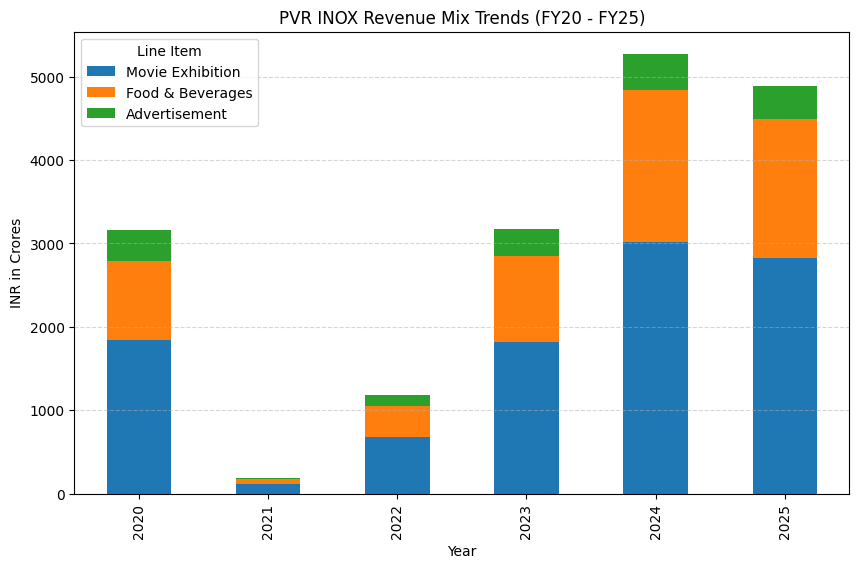

In [6]:
# Transpose so years become the index rows and line items become columns
df_ts = df.T
df_ts.index = df_ts.index.astype(int)

# Quick plot check for Revenue Segments
df_ts[['Movie Exhibition', 'Food & Beverages', 'Advertisement']].plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('PVR INOX Revenue Mix Trends (FY20 - FY25)')
plt.ylabel('INR in Crores')
plt.xlabel('Year')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Plot saved successfully as pvr_inox_cogs_split.png

Percentage Breakdown Table:
Line Item  Movie exhibition cost  Consumption of food and beverages
2020                   64.794235                          35.205765
2021                   58.430541                          41.569459
2022                   63.960268                          36.039732
2023                   65.649328                          34.350672
2024                   64.424167                          35.575833
2025                   63.836586                          36.163414


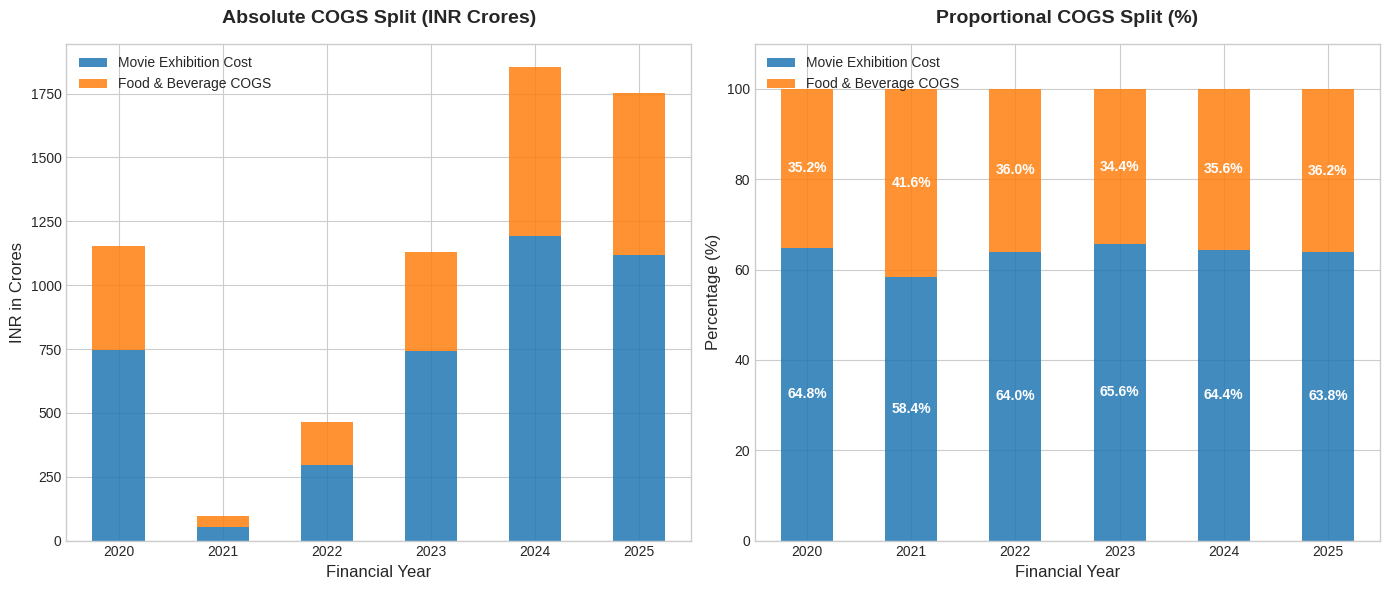

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the generated CSV
df = pd.read_csv('pvr_inox_standalone_is.csv', index_col=0)

# Extract relevant rows
cost_items = ['Movie exhibition cost', 'Consumption of food and beverages']
df_costs = df.loc[cost_items].T
df_costs.index = df_costs.index.astype(int)

# Create a 100% stacked bar chart to show the split percentage
df_percentage = df_costs.div(df_costs.sum(axis=1), axis=0) * 100

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Absolute values
df_costs.plot(kind='bar', stacked=True, ax=ax1, color=['#1f77b4', '#ff7f0e'], alpha=0.85)
ax1.set_title('Absolute COGS Split (INR Crores)', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('INR in Crores', fontsize=12)
ax1.set_xlabel('Financial Year', fontsize=12)
ax1.tick_params(axis='x', rotation=0)
ax1.legend(['Movie Exhibition Cost', 'Food & Beverage COGS'], loc='upper left')

# Plot 2: Percentage Split (100% Stacked)
df_percentage.plot(kind='bar', stacked=True, ax=ax2, color=['#1f77b4', '#ff7f0e'], alpha=0.85)
ax2.set_title('Proportional COGS Split (%)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_xlabel('Financial Year', fontsize=12)
ax2.tick_params(axis='x', rotation=0)
ax2.set_ylim(0, 110)
ax2.legend(['Movie Exhibition Cost', 'Food & Beverage COGS'], loc='upper left')

# Add percentage labels inside the bars
for p in ax2.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 5: # Only show label if the bar slice is large enough
        ax2.text(x + width/2,
                 y + height/2,
                 f'{height:.1f}%',
                 horizontalalignment='center',
                 verticalalignment='center',
                 color='white',
                 fontweight='bold',
                 fontsize=10)

plt.tight_layout()
plt.savefig('pvr_inox_cogs_split.png', dpi=300)
print("Plot saved successfully as pvr_inox_cogs_split.png")
print("\nPercentage Breakdown Table:")
print(df_percentage)